# Notebook 06 — ResNet18 Transfer Learning

**არქიტექტურა #5: ResNet18 (pretrained ImageNet) + transfer learning**

VGG+aug-მა 70%-ს მიაღწია from scratch. ახლა ვცადოთ transfer learning — pretrained ResNet18 ImageNet-დან. იდეა მარტივია: ResNet-მა უკვე ისწავლა edge/texture/face features ImageNet-ზე, ჩვენ ვაიყვანთ ამ პრე-learned features-ს FER2013-ისთვის.

**პრობლემები რომელიც ჯერ უნდა მოვაგვაროთ:**
- FER2013 = 48×48 grayscale; ResNet18 = 224×224 RGB → უნდა resize + replicate to 3 channels + ImageNet normalize
- ResNet ბევრად დიდია (~11M params), მაგრამ ფინეთიუნ-ისთვის ცოტა epoch საკმარისია

**3 runs (progressive unfreezing):**
1. **A** — frozen backbone, ვწვრთნით მხოლოდ ახალ FC layer-ს ("linear probing")
2. **B** — last block (layer4) + FC unfrozen
3. **C** — full fine-tune, very low LR


In [2]:
# Setup
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import os
PROJECT_DIR = '/content/drive/MyDrive/ML_davaleba_4'
os.chdir(PROJECT_DIR)

import sys
sys.path.insert(0, f'{PROJECT_DIR}/src')

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import transforms, models
import wandb

from utils import (
    load_fer2013, get_dataloaders, count_parameters,
    sanity_check_forward, train_model, evaluate, plot_training_curves,
    get_predictions, plot_confusion_matrix, print_classification_report,
    set_seed,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda


In [3]:
# WandB login
try:
    from google.colab import userdata
    WANDB_API_KEY = userdata.get('WANDB_API_KEY')
except Exception:
    WANDB_API_KEY = "API_KEY"

wandb.login(key=WANDB_API_KEY)
PROJECT = "ml_davaleba_4"

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: zberi23 (zberi23_ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## ResNet-ისთვის Transform Pipeline

48×48 grayscale → 224×224 RGB + ImageNet normalization.

In [4]:
class NumpyToTensor:
    """(48, 48) uint8 → (1, 48, 48) float [0, 1]."""
    def __call__(self, img):
        return torch.from_numpy(img.astype(np.float32) / 255.0).unsqueeze(0)


# ImageNet stats
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


train_resnet_transform = transforms.Compose([
    NumpyToTensor(),
    transforms.Resize(224, antialias=True),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),     # grayscale → RGB
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=10, translate=(0.05, 0.05)),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_resnet_transform = transforms.Compose([
    NumpyToTensor(),
    transforms.Resize(224, antialias=True),
    transforms.Lambda(lambda x: x.repeat(3, 1, 1)),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

In [5]:
# Data loading
X_train, y_train, X_val, y_val, X_test, y_test = load_fer2013(
    f'{PROJECT_DIR}/data/fer2013_processed.npz'
)

BATCH_SIZE = 64  # ResNet18-ისთვის T4-ზე ნორმალურია
train_loader, val_loader, test_loader = get_dataloaders(
    X_train, y_train, X_val, y_val, X_test, y_test,
    batch_size=BATCH_SIZE, num_workers=0,
    train_transform=train_resnet_transform, eval_transform=eval_resnet_transform
)

print(f"Train batches: {len(train_loader)}, Val: {len(val_loader)}, Test: {len(test_loader)}")
# შემოწმება: pulls out one batch and checks shape
X_sample, y_sample = next(iter(train_loader))
print(f"Sample batch shape: {X_sample.shape}")  # უნდა იყოს (64, 3, 224, 224)

Train batches: 449, Val: 57, Test: 57
Sample batch shape: torch.Size([64, 3, 224, 224])


## ResNet18 Setup

ვტვირთავთ ImageNet-ზე pretrained ResNet18-ს და ვცვლით ბოლო FC layer-ს (1000 → 7 classes).

In [6]:
def make_resnet18(freeze_mode='none', num_classes=7):
    """
    freeze_mode:
        'all'     — ყველაფერი frozen გარდა ახალი FC-ისა (linear probing)
        'partial' — მხოლოდ layer4 + FC trainable
        'none'    — ყველაფერი trainable (full fine-tune)
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_mode == 'all':
        for p in model.parameters():
            p.requires_grad = False
    elif freeze_mode == 'partial':
        for p in model.parameters():
            p.requires_grad = False
        # ვათავისუფლებთ layer4-ს
        for p in model.layer4.parameters():
            p.requires_grad = True
    # 'none' = ყველაფერი trainable რჩება

    # ვცვლით ბოლო FC-ს
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# პარამეტრების ბროვერი
for mode in ['all', 'partial', 'none']:
    m = make_resnet18(freeze_mode=mode)
    n_train = sum(p.numel() for p in m.parameters() if p.requires_grad)
    n_total = sum(p.numel() for p in m.parameters())
    print(f"  freeze_mode='{mode}': trainable {n_train:,} / {n_total:,} ({100*n_train/n_total:.1f}%)")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 109MB/s]


  freeze_mode='all': trainable 3,591 / 11,180,103 (0.0%)
  freeze_mode='partial': trainable 8,397,319 / 11,180,103 (75.1%)
  freeze_mode='none': trainable 11,180,103 / 11,180,103 (100.0%)


## Sanity Check

In [7]:
set_seed(42)
model = make_resnet18(freeze_mode='all').to(device)
criterion = nn.CrossEntropyLoss()
_ = sanity_check_forward(model, train_loader, criterion, device)

=== Forward Pass Sanity Check ===
  Batch input shape:  (64, 3, 224, 224)
  Batch output shape: (64, 7)
  Initial loss:       2.0671
  Expected (random):  1.9459  = log(7)
  Diff:               0.1212
  Trainable params:   3,591


## Run A — Linear Probing (frozen backbone)

backbone-ი ფიქსირდება, ვწვრთნით მხოლოდ ახალ FC layer-ს. ImageNet features-ი როგორი feature extractor-ია ვნახოთ.

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   1/10 | train_loss 1.6305 acc 0.3600 | val_loss 1.5805 acc 0.3798 | grad 3.217 | lr 1.00e-03
Epoch   2/10 | train_loss 1.5311 acc 0.4098 | val_loss 1.5322 acc 0.4110 | grad 3.067 | lr 9.76e-04
Epoch   3/10 | train_loss 1.5132 acc 0.4154 | val_loss 1.5064 acc 0.4269 | grad 3.092 | lr 9.05e-04
Epoch   4/10 | train_loss 1.4924 acc 0.4284 | val_loss 1.5136 acc 0.4218 | grad 3.033 | lr 7.94e-04
Epoch   5/10 | train_loss 1.4830 acc 0.4299 | val_loss 1.5146 acc 0.4099 | grad 2.969 | lr 6.55e-04
Epoch   6/10 | train_loss 1.4698 acc 0.4358 | val_loss 1.4896 acc 0.4338 | grad 2.797 | lr 5.00e-04
Epoch   7/10 | train_loss 1.4673 acc 0.4379 | val_loss 1.4962 acc 0.4316 | grad 2.811 | lr 3.45e-04
Epoch   8/10 | train_loss 1.4651 acc 0.4370 | val_loss 1.4996 acc 0.4308 | grad 2.775 | lr 2.06e-04
Epoch   9/10 | train_loss 1.4538 acc 0.4422 | val_loss 1.4980 acc 0.4319 | grad 2.700 | lr 9.55e-05
Epoch  10/10 | train_loss 1.4537 acc 0.4437 | val_loss 1.4928 acc 0.4313 | grad 2.606 | lr 2.45e-05


best_val_acc,▁
epoch,▁▂▃▃▄▅▆▆▇█
grad_norm,█▆▇▆▅▃▃▃▂▁
lr,██▇▇▆▄▃▂▂▁
train_acc,▁▅▆▇▇▇█▇██
train_loss,█▄▃▃▂▂▂▁▁▁
val_acc,▁▅▇▆▅█████
val_loss,█▄▂▃▃▁▂▂▂▁
best_val_acc,0.43383
epoch,10
grad_norm,2.60602


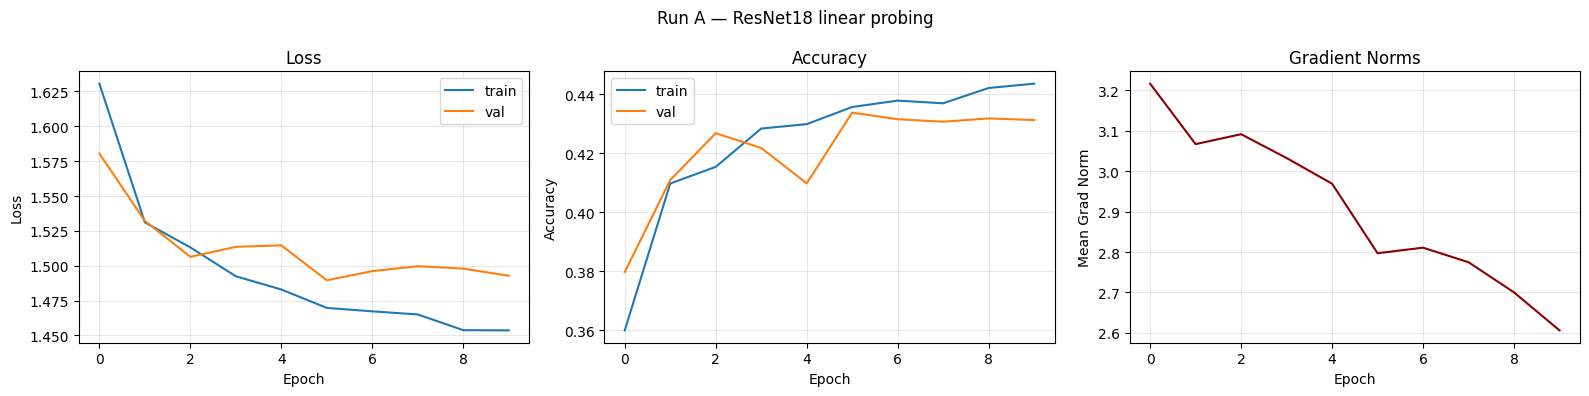

Best val acc: 0.4338
Train-Val gap: 0.0123


In [8]:
# Run A — frozen backbone (linear probing)
set_seed(42)
model_a = make_resnet18(freeze_mode='all').to(device)

# მხოლოდ FC-ის parameters წავიდეს optimizer-ში
optimizer_a = optim.Adam([p for p in model_a.parameters() if p.requires_grad], lr=1e-3)
scheduler_a = optim.lr_scheduler.CosineAnnealingLR(optimizer_a, T_max=10)

config_a = {
    'architecture': 'ResNet18',
    'num_params_trainable': sum(p.numel() for p in model_a.parameters() if p.requires_grad),
    'freeze_mode': 'all (linear probing)',
    'optimizer': 'Adam',
    'lr': 1e-3,
    'lr_scheduler': 'CosineAnnealingLR',
    'augmentation': 'mild',
    'batch_size': BATCH_SIZE,
    'num_epochs': 10,
    'pretrained': 'ImageNet',
}

history_a, best_acc_a = train_model(
    model_a, train_loader, val_loader, optimizer_a, criterion, device,
    num_epochs=10, scheduler=scheduler_a,
    run_name='06_resnet18_linear_probe',
    project=PROJECT, config=config_a,
    save_path=f'{PROJECT_DIR}/models/06_resnet18_linear.pt'
)
wandb.finish()
plot_training_curves(history_a, title="Run A — ResNet18 linear probing")
print(f"Best val acc: {best_acc_a:.4f}")
print(f"Train-Val gap: {history_a['train_acc'][-1] - history_a['val_acc'][-1]:.4f}")

## Run B — Partial Unfreeze (layer4 + FC)

layer4 (ბოლო residual block) + ახალი FC trainable, წინა layers frozen. ImageNet features-ი მაღალი დონის features-ისთვის ვაადაპტირებთ.

Epoch   1/12 | train_loss 1.2041 acc 0.5476 | val_loss 1.1191 acc 0.5759 | grad 2.693 | lr 5.00e-04
Epoch   2/12 | train_loss 1.0272 acc 0.6163 | val_loss 1.0409 acc 0.6108 | grad 2.224 | lr 4.91e-04
Epoch   3/12 | train_loss 0.9611 acc 0.6381 | val_loss 1.0373 acc 0.6211 | grad 2.149 | lr 4.67e-04
Epoch   4/12 | train_loss 0.8994 acc 0.6616 | val_loss 1.0133 acc 0.6378 | grad 2.100 | lr 4.27e-04
Epoch   5/12 | train_loss 0.8427 acc 0.6849 | val_loss 0.9620 acc 0.6478 | grad 2.109 | lr 3.75e-04
Epoch   6/12 | train_loss 0.7783 acc 0.7109 | val_loss 0.9908 acc 0.6484 | grad 2.129 | lr 3.15e-04
Epoch   7/12 | train_loss 0.7138 acc 0.7362 | val_loss 1.0087 acc 0.6525 | grad 2.241 | lr 2.50e-04
Epoch   8/12 | train_loss 0.6404 acc 0.7633 | val_loss 1.0341 acc 0.6615 | grad 2.396 | lr 1.85e-04
Epoch   9/12 | train_loss 0.5573 acc 0.7964 | val_loss 1.0665 acc 0.6654 | grad 2.531 | lr 1.25e-04
Epoch  10/12 | train_loss 0.4830 acc 0.8267 | val_loss 1.0791 acc 0.6709 | grad 2.657 | lr 7.32e-05


best_val_acc,▁
epoch,▁▂▂▃▄▄▅▅▆▇▇█
grad_norm,▇▂▂▁▁▁▂▄▆▇██
lr,███▇▆▅▄▄▃▂▁▁
train_acc,▁▃▃▄▄▅▅▆▇▇██
train_loss,█▆▆▅▅▄▄▃▂▂▁▁
val_acc,▁▄▄▆▆▆▇▇████
val_loss,█▄▄▃▁▂▃▄▆▆██
best_val_acc,0.67094
epoch,12
grad_norm,2.7499


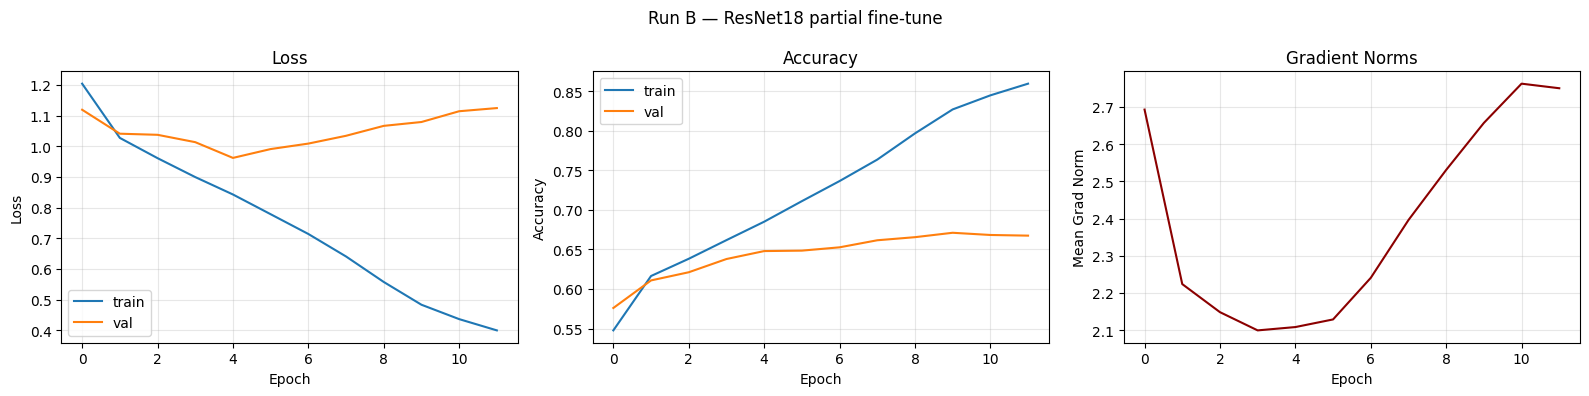

Best val acc: 0.6709
Train-Val gap: 0.1920


In [9]:
# Run B — partial fine-tune (layer4 + FC)
set_seed(42)
model_b = make_resnet18(freeze_mode='partial').to(device)
optimizer_b = optim.Adam([p for p in model_b.parameters() if p.requires_grad],
                          lr=5e-4, weight_decay=1e-4)
scheduler_b = optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=12)

config_b = {
    'architecture': 'ResNet18',
    'num_params_trainable': sum(p.numel() for p in model_b.parameters() if p.requires_grad),
    'freeze_mode': 'partial (layer4 + FC)',
    'optimizer': 'Adam',
    'lr': 5e-4,
    'weight_decay': 1e-4,
    'lr_scheduler': 'CosineAnnealingLR',
    'augmentation': 'mild',
    'batch_size': BATCH_SIZE,
    'num_epochs': 12,
}

history_b, best_acc_b = train_model(
    model_b, train_loader, val_loader, optimizer_b, criterion, device,
    num_epochs=12, scheduler=scheduler_b,
    run_name='06_resnet18_partial_finetune',
    project=PROJECT, config=config_b,
    save_path=f'{PROJECT_DIR}/models/06_resnet18_partial.pt'
)
wandb.finish()
plot_training_curves(history_b, title="Run B — ResNet18 partial fine-tune")
print(f"Best val acc: {best_acc_b:.4f}")
print(f"Train-Val gap: {history_b['train_acc'][-1] - history_b['val_acc'][-1]:.4f}")

## Run C — Full Fine-tune

ყველაფერი trainable, very low lr (რომ pretrained features არ წავშალოთ).  
ჯერჯერობით საუკეთესო configuration-ი.

Epoch   1/15 | train_loss 1.1604 acc 0.5645 | val_loss 1.0003 acc 0.6236 | grad 5.756 | lr 1.00e-04
Epoch   2/15 | train_loss 0.9307 acc 0.6540 | val_loss 0.9569 acc 0.6450 | grad 4.663 | lr 9.89e-05
Epoch   3/15 | train_loss 0.8439 acc 0.6856 | val_loss 0.9460 acc 0.6612 | grad 4.496 | lr 9.57e-05
Epoch   4/15 | train_loss 0.7611 acc 0.7192 | val_loss 0.9077 acc 0.6726 | grad 4.589 | lr 9.05e-05
Epoch   5/15 | train_loss 0.6843 acc 0.7484 | val_loss 0.9680 acc 0.6570 | grad 4.800 | lr 8.35e-05
Epoch   6/15 | train_loss 0.6070 acc 0.7771 | val_loss 0.9429 acc 0.6804 | grad 5.039 | lr 7.50e-05
Epoch   7/15 | train_loss 0.5304 acc 0.8109 | val_loss 0.9543 acc 0.6918 | grad 5.242 | lr 6.55e-05
Epoch   8/15 | train_loss 0.4556 acc 0.8355 | val_loss 0.9876 acc 0.6930 | grad 5.501 | lr 5.52e-05
Epoch   9/15 | train_loss 0.3733 acc 0.8701 | val_loss 1.0393 acc 0.6868 | grad 5.506 | lr 4.48e-05
Epoch  10/15 | train_loss 0.3104 acc 0.8941 | val_loss 1.0520 acc 0.6893 | grad 5.555 | lr 3.45e-05


best_val_acc,▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
grad_norm,█▂▁▂▃▄▅▇▇▇▆▆▄▄▃
lr,███▇▇▆▆▅▄▃▃▂▂▁▁
train_acc,▁▃▃▄▄▅▅▆▇▇▇████
train_loss,█▆▆▅▅▄▄▃▂▂▂▁▁▁▁
val_acc,▁▃▅▆▄▆▇█▇▇██▇██
val_loss,▄▃▂▁▃▂▃▄▆▆▆▇███
best_val_acc,0.69824
epoch,15
grad_norm,4.86944


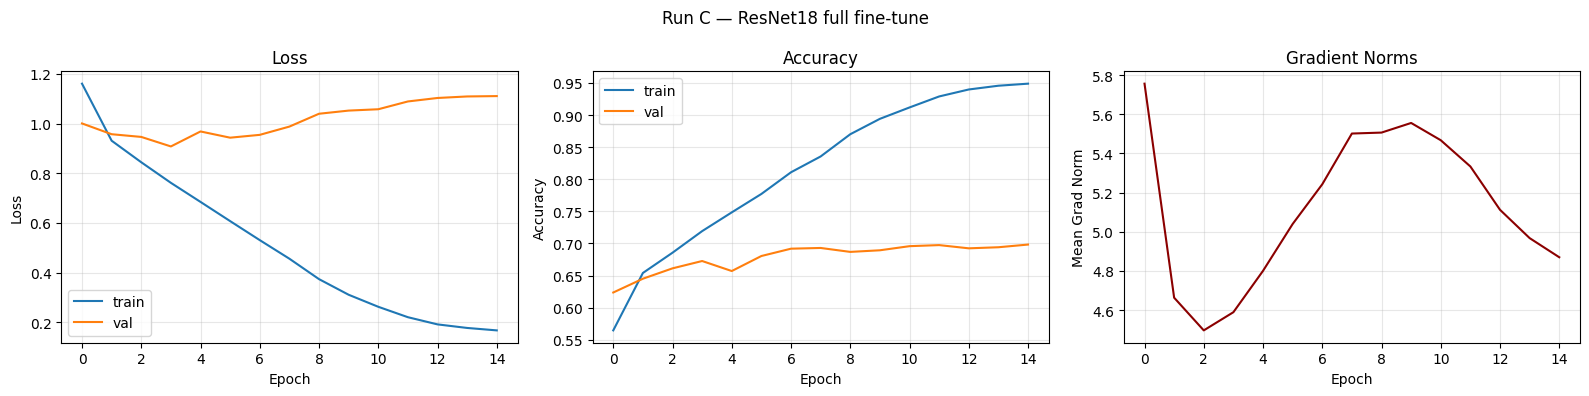

Best val acc: 0.6982
Train-Val gap: 0.2507


In [10]:
# Run C — full fine-tune, low LR
set_seed(42)
model_c = make_resnet18(freeze_mode='none').to(device)
optimizer_c = optim.Adam(model_c.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_c = optim.lr_scheduler.CosineAnnealingLR(optimizer_c, T_max=15)

config_c = {
    'architecture': 'ResNet18',
    'num_params_trainable': sum(p.numel() for p in model_c.parameters() if p.requires_grad),
    'freeze_mode': 'none (full fine-tune)',
    'optimizer': 'Adam',
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'lr_scheduler': 'CosineAnnealingLR',
    'augmentation': 'mild',
    'batch_size': BATCH_SIZE,
    'num_epochs': 15,
}

history_c, best_acc_c = train_model(
    model_c, train_loader, val_loader, optimizer_c, criterion, device,
    num_epochs=15, scheduler=scheduler_c,
    run_name='06_resnet18_full_finetune',
    project=PROJECT, config=config_c,
    save_path=f'{PROJECT_DIR}/models/06_resnet18_full.pt'
)
wandb.finish()
plot_training_curves(history_c, title="Run C — ResNet18 full fine-tune")
print(f"Best val acc: {best_acc_c:.4f}")
print(f"Train-Val gap: {history_c['train_acc'][-1] - history_c['val_acc'][-1]:.4f}")

## Run-ების შედარება

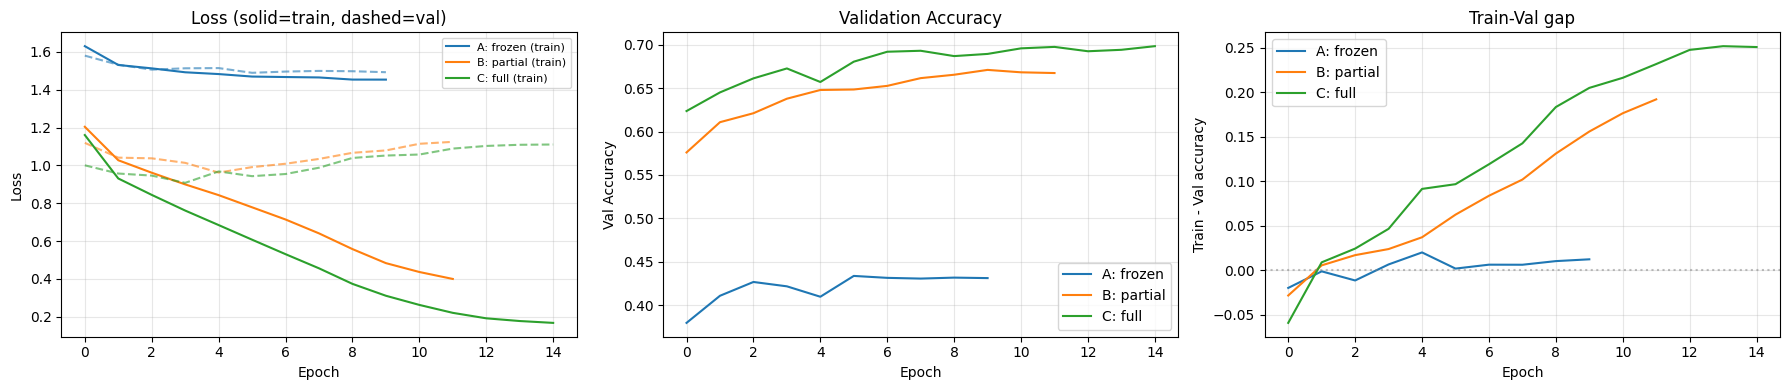


Final val accuracy comparison:
  Run A (linear probe):   0.4338  [gap: +0.0123]
  Run B (partial unfreeze): 0.6709  [gap: +0.1920]
  Run C (full fine-tune): 0.6982  [gap: +0.2507]


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(history_a['train_loss'], label='A: frozen (train)', linestyle='-')
axes[0].plot(history_a['val_loss'], linestyle='--', alpha=0.6, color='C0')
axes[0].plot(history_b['train_loss'], label='B: partial (train)', linestyle='-')
axes[0].plot(history_b['val_loss'], linestyle='--', alpha=0.6, color='C1')
axes[0].plot(history_c['train_loss'], label='C: full (train)', linestyle='-')
axes[0].plot(history_c['val_loss'], linestyle='--', alpha=0.6, color='C2')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss (solid=train, dashed=val)'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(history_a['val_acc'], label='A: frozen')
axes[1].plot(history_b['val_acc'], label='B: partial')
axes[1].plot(history_c['val_acc'], label='C: full')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Validation Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

for h, label in [(history_a, 'A: frozen'), (history_b, 'B: partial'), (history_c, 'C: full')]:
    gaps = [t - v for t, v in zip(h['train_acc'], h['val_acc'])]
    axes[2].plot(gaps, label=label)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Train - Val accuracy')
axes[2].set_title('Train-Val gap')
axes[2].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nFinal val accuracy comparison:")
print(f"  Run A (linear probe):   {best_acc_a:.4f}  [gap: {history_a['train_acc'][-1] - history_a['val_acc'][-1]:+.4f}]")
print(f"  Run B (partial unfreeze): {best_acc_b:.4f}  [gap: {history_b['train_acc'][-1] - history_b['val_acc'][-1]:+.4f}]")
print(f"  Run C (full fine-tune): {best_acc_c:.4f}  [gap: {history_c['train_acc'][-1] - history_c['val_acc'][-1]:+.4f}]")

## საუკეთესო Run-ის Test Evaluation

საუკეთესო Run: C (val_acc=0.6982)

Test loss: 1.0062
Test accuracy: 0.7169


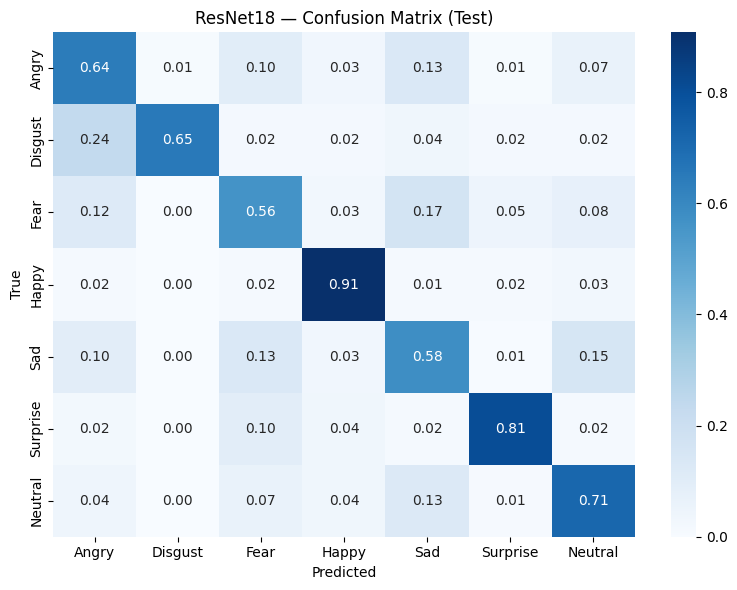

              precision    recall  f1-score   support

       Angry     0.6320    0.6436    0.6377       491
     Disgust     0.8000    0.6545    0.7200        55
        Fear     0.5670    0.5606    0.5638       528
       Happy     0.8966    0.9078    0.9022       879
         Sad     0.5743    0.5791    0.5767       594
    Surprise     0.8615    0.8077    0.8337       416
     Neutral     0.6952    0.7141    0.7045       626

    accuracy                         0.7169      3589
   macro avg     0.7181    0.6954    0.7055      3589
weighted avg     0.7179    0.7169    0.7172      3589



In [12]:
best_runs = {
    'A': (best_acc_a, f'{PROJECT_DIR}/models/06_resnet18_linear.pt', 'all'),
    'B': (best_acc_b, f'{PROJECT_DIR}/models/06_resnet18_partial.pt', 'partial'),
    'C': (best_acc_c, f'{PROJECT_DIR}/models/06_resnet18_full.pt', 'none'),
}
best_label = max(best_runs, key=lambda k: best_runs[k][0])
best_acc, best_path, best_freeze = best_runs[best_label]
print(f"საუკეთესო Run: {best_label} (val_acc={best_acc:.4f})")

best_model = make_resnet18(freeze_mode=best_freeze).to(device)
best_model.load_state_dict(torch.load(best_path))

test_loss, test_acc = evaluate(best_model, test_loader, criterion, device)
print(f"\nTest loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

preds, labels = get_predictions(best_model, test_loader, device)
_ = plot_confusion_matrix(preds, labels, title="ResNet18 — Confusion Matrix (Test)")
print_classification_report(preds, labels)

## ანალიზი

**შედეგები:**
- Run A (linear probe): val **43.38%**, gap **1.2%** — ImageNet features მარტო ცუდად მუშაობს faces-ისთვის
- Run B (partial, layer4+FC): val **67.09%**, gap 19.2% — დიდი ნახტომი როცა layer4 ვათავისუფლებთ
- Run C (full fine-tune): val **69.82%**, **test 71.69%**, gap 25% — საუკეთესო

**მთავარი:** transfer learning მუშაობს, მაგრამ მოლოდინზე ნაკლები ეფექტი (+1.2pp from VGG+aug). მიზეზები:
- FER2013 grayscale → 3 channel replication ნამდვილ RGB info-ს არ ემატება
- ImageNet (natural images) ≠ FER2013 (faces) — domain shift
- 48×48 → 224×224 upsampling, რეალურ info-ს არ ვამატებთ

**per-class F1 (VGG+aug → ResNet18):**
- Happy: 0.88 → **0.90**
- Surprise: 0.79 → **0.83**  
- Macro F1: 0.69 → **0.71**
- Test acc: 70.47% → **71.69%**

---

## საბოლოო შედარება

| # | Architecture | Test Acc | Macro F1 | Gap |
|---|---|---|---|---|
| 1 | TinyCNN | 45.22% | 0.40 | small (underfit) |
| 2 | SmallCNN | 56.45% | 0.53 | 43% (overfit!) |
| 3 | MediumCNN+BN+Drop | 60.69% | 0.59 | 40% |
| 4 | VGG+aug | 70.47% | 0.69 | 6% |
| 5 | ResNet18 fine-tune | **71.69%** | **0.71** | 25% |

➡️ ბოლო ნაბიჯი: README.md + GitHub push + WandB Report